# Dict Expander Example

This notebook reads `dictExpander.csv`, renames columns using the text after `#`, then parses dict/list strings stored in CSV cells.

In [12]:
import pandas as pd
import numpy as np
from pandas import Timestamp

csv_file = "dictExpander.csv"

In [13]:
def rename_columns(df):
    df.columns = [c.split("#")[-1].strip() for c in df.columns]
    for c in df.columns[df.iloc[0].astype(str).str[0].isin(["[", "{"])]:
        v = df[c].map(lambda s: eval(s, {"Timestamp": pd.Timestamp, "pd": pd, "np": np}) if isinstance(s, str) and s[:1] in "[{" else None)
        fill = {} if isinstance(v.dropna().iloc[0], dict) else []
        df = df.drop(columns=c).join(pd.DataFrame(v.map(lambda x: x if x is not None else fill).tolist(), index=df.index).add_prefix(f"{c}."))
    return df


In [14]:
# 

In [15]:
### BAD versions

# g = {"np": np, "pd": pd, "Timestamp": pd.Timestamp, "array": np.array}

# def rename_columns(df):
#     df.columns = [c.split("#")[-1].strip() for c in df.columns]
#     df = df.map(lambda x: eval(x, g) if isinstance(x, str) else x)
#     return pd.concat(
#         [pd.json_normalize(df[c]).add_prefix(c + ".") if isinstance(df[c].iloc[0], dict) else df[c]
#          for c in df],
#         axis=1
#     )

# def rename_columns_minimal(df):
#     df.columns = [c.split("#")[-1].strip() for c in df.columns]
#     g = {"np": np, "pd": pd, "Timestamp": pd.Timestamp, "array": np.array}
#     df = df.map(lambda s: eval(s, g) if isinstance(s, str) and s[:1] in "[{" else s)
#     return pd.json_normalize(df.to_dict('records'))


# g = {"np": np, "pd": pd, "Timestamp": pd.Timestamp, "array": np.array}

# def rename_columns(df):
#     df.columns = [c.split("#")[-1].strip() for c in df.columns]
#     df = df.map(lambda x: eval(x, g))
#     return pd.concat([pd.json_normalize(df[c]).add_prefix(c + ".") if isinstance(df[c][0], dict) else df[c] for c in df], axis=1)

# Minimalist version (unpacks dicts, keeps arrays):
# def rename_columns(df):
#     df.columns = [c.split("#")[-1].strip() for c in df.columns]
#     g = {"np": np, "pd": pd, "Timestamp": pd.Timestamp, "array": np.array}
#     for c in df.columns:
#         df[c] = df[c].map(lambda s: eval(s, g) if isinstance(s, str) and s[:1] in "[{" else s)
#     return pd.json_normalize(df.to_dict('records'))

In [16]:
raw = pd.read_csv(csv_file, comment=";")
raw.head()

,pd.Timestamp.now #now,repeat,randomDict # dic,randomlist #lis
0,2026-05-12 16:45:32.378986,0,{'timestamp': Timestamp('2026-05-12 16:45:32.3...,"[Timestamp('2026-05-12 16:45:32.378986'), 0.96..."
1,2026-05-12 16:45:35.395053,1,{'timestamp': Timestamp('2026-05-12 16:45:35.3...,"[Timestamp('2026-05-12 16:45:35.395053'), 0.34..."
2,2026-05-12 16:45:38.406482,2,{'timestamp': Timestamp('2026-05-12 16:45:38.4...,"[Timestamp('2026-05-12 16:45:38.406482'), 0.49..."
3,2026-05-12 16:45:41.415902,3,{'timestamp': Timestamp('2026-05-12 16:45:41.4...,"[Timestamp('2026-05-12 16:45:41.415902'), 0.99..."
4,2026-05-12 16:45:44.425139,4,{'timestamp': Timestamp('2026-05-12 16:45:44.4...,"[Timestamp('2026-05-12 16:45:44.425139'), 0.57..."


In [17]:
df = rename_columns(raw)
df

,now,repeat,dic.timestamp,dic.x,dic.y,dic.label,lis.0,lis.1,lis.2
0,2026-05-12 16:45:32.378986,0,2026-05-12 16:45:32.378986,0.247665,0.696622,one dict in one csv cell,2026-05-12 16:45:32.378986,0.965981,0.319329
1,2026-05-12 16:45:35.395053,1,2026-05-12 16:45:35.395053,0.233787,0.109380,one dict in one csv cell,2026-05-12 16:45:35.395053,0.343537,0.926184
2,2026-05-12 16:45:38.406482,2,2026-05-12 16:45:38.406482,0.734069,0.906630,one dict in one csv cell,2026-05-12 16:45:38.406482,0.497949,0.729641
3,2026-05-12 16:45:41.415902,3,2026-05-12 16:45:41.415902,0.641854,0.564413,one dict in one csv cell,2026-05-12 16:45:41.415902,0.997048,0.263167
4,2026-05-12 16:45:44.425139,4,2026-05-12 16:45:44.425139,0.523382,0.945912,one dict in one csv cell,2026-05-12 16:45:44.425139,0.571341,0.999792
5,2026-05-12 16:45:47.432819,5,2026-05-12 16:45:47.433820,0.005326,0.277098,one dict in one csv cell,2026-05-12 16:45:47.433820,0.088086,0.290593
6,2026-05-12 16:45:50.441168,6,2026-05-12 16:45:50.441168,0.369006,0.387622,one dict in one csv cell,2026-05-12 16:45:50.441168,0.761928,0.609975
7,2026-05-12 16:45:53.449354,7,2026-05-12 16:45:53.449354,0.857080,0.258723,one dict in one csv cell,2026-05-12 16:45:53.449354,0.022999,0.775007
8,2026-05-12 16:45:56.460633,8,2026-05-12 16:45:56.460633,0.492862,0.019421,one dict in one csv cell,2026-05-12 16:45:56.461630,0.092644,0.374038
9,2026-05-12 16:45:59.471848,9,2026-05-12 16:45:59.471848,0.509428,0.798962,one dict in one csv cell,2026-05-12 16:45:59.471848,0.667843,0.733902


In [18]:
df.columns

Index(['now', 'repeat', 'dic.timestamp', 'dic.x', 'dic.y', 'dic.label',
       'lis.0', 'lis.1', 'lis.2'],
      dtype='str')

<Axes: xlabel='repeat'>

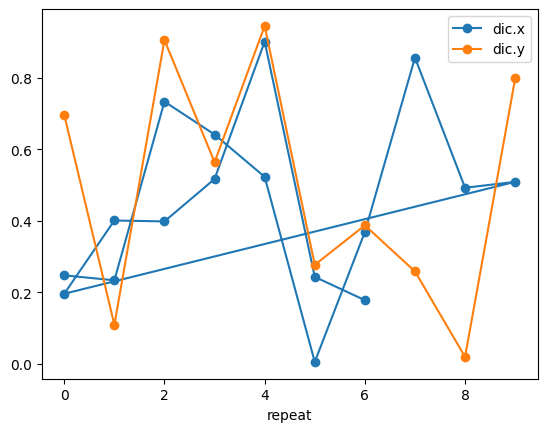

In [19]:
df.plot(x="repeat", y=["dic.x", "dic.y"], marker="o")